# 02 — EDA: Time, delays, and routes

**Delivery ETA Intelligence**

This notebook explores **time-related patterns** and **route behavior** to support ETA prediction and network intelligence.

**Prerequisites:** Run `01_dataset_understanding.ipynb` first, or ensure `data/raw/delivery_data.csv` is in place.

## What we will learn

- How **actual** transit times compare to **OSRM** (map-based) estimates
- Where **delays** concentrate (ratios, outliers, invalid rows)
- How **FTL** (full truck load) differs from **Carting**
- Which **hubs** and **lanes** are busiest or most delayed

These insights guide feature engineering in `src/` and graph construction in later notebooks.

## 1. Setup — imports and plotting style

We use **pathlib** for paths (works on any OS) and set a consistent chart style.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 2. Load the dataset

The file lives under `data/raw/`. We resolve the **project root** so the notebook works whether you start Jupyter from the project folder or from `notebooks/`.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "delivery_data.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns from:\n  {DATA_PATH}")

Loaded 144,867 rows × 24 columns from:
  D:\delivery eta\data\raw\delivery_data.csv


## 3. Parse datetime columns

Timestamps are stored as text in the CSV. We convert them to proper `datetime64` values (UTC) so we can extract **hour** and **day-of-week** features.

| Column | Meaning |
|--------|--------|
| `trip_creation_time` | When the trip was created |
| `od_start_time` | Segment / OD start |
| `od_end_time` | Segment / OD end |
| `cutoff_timestamp` | Operational cutoff window |

In [3]:
DATETIME_COLS = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp",
]

for col in DATETIME_COLS:
    df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

parsed_ok = df[DATETIME_COLS].notna().all(axis=1).mean() * 100
print(f"Rows with all datetimes parsed: {parsed_ok:.2f}%")
df[DATETIME_COLS].head()

Rows with all datetimes parsed: 97.63%


,trip_creation_time,od_start_time,od_end_time,cutoff_timestamp
0,2018-09-20 02:35:36.476840+00:00,2018-09-20 03:21:32.418600+00:00,2018-09-20 04:47:45.236797+00:00,2018-09-20 04:27:55+00:00
1,2018-09-20 02:35:36.476840+00:00,2018-09-20 03:21:32.418600+00:00,2018-09-20 04:47:45.236797+00:00,2018-09-20 04:17:55+00:00
2,2018-09-20 02:35:36.476840+00:00,2018-09-20 03:21:32.418600+00:00,2018-09-20 04:47:45.236797+00:00,NaT
3,2018-09-20 02:35:36.476840+00:00,2018-09-20 03:21:32.418600+00:00,2018-09-20 04:47:45.236797+00:00,2018-09-20 03:39:57+00:00
4,2018-09-20 02:35:36.476840+00:00,2018-09-20 03:21:32.418600+00:00,2018-09-20 04:47:45.236797+00:00,2018-09-20 03:33:55+00:00


## 4. Derived features for ETA analysis

- **`delay_ratio`** = `actual_time / osrm_time` — trip-level actual vs. routing estimate (>1 means slower than OSRM).
- **`segment_delay_ratio`** = `segment_actual_time / segment_osrm_time` — same idea per segment.
- **`trip_hour`** / **`trip_dayofweek`** — temporal patterns from trip creation (0=Monday in pandas).

We use safe division: if OSRM time is 0 or missing, the ratio is set to `NaN` instead of infinity.

In [4]:
def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Divide only where denominator is positive; else NaN."""
    denom = denominator.replace(0, np.nan)
    return numerator / denom


df["delay_ratio"] = safe_ratio(df["actual_time"], df["osrm_time"])
df["segment_delay_ratio"] = safe_ratio(df["segment_actual_time"], df["segment_osrm_time"])

df["trip_hour"] = df["trip_creation_time"].dt.hour
df["trip_dayofweek"] = df["trip_creation_time"].dt.dayofweek
df["trip_day_name"] = df["trip_creation_time"].dt.day_name()

# Lane identifier for route-level summaries
df["route_lane"] = df["source_center"].astype(str) + " → " + df["destination_center"].astype(str)

df[["actual_time", "osrm_time", "delay_ratio", "segment_delay_ratio", "trip_hour", "trip_dayofweek"]].head()

,actual_time,osrm_time,delay_ratio,segment_delay_ratio,trip_hour,trip_dayofweek
0,14.0,11.0,1.272727,1.272727,2,3
1,24.0,20.0,1.200000,1.111111,2,3
2,40.0,28.0,1.428571,2.285714,2,3
3,62.0,40.0,1.550000,1.750000,2,3
4,68.0,44.0,1.545455,1.200000,2,3


## 5. Univariate analysis — distributions, skewness, outliers

We focus on four variables that matter for ETA modeling:

- **`actual_time`** — observed duration (minutes)
- **`osrm_time`** — routing-engine estimate
- **`delay_ratio`** / **`segment_delay_ratio`** — how much reality exceeds the map

**Skewness:** positive skew means a long right tail (a few very large values).  
**Outliers (IQR rule):** values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.

In [5]:
UNIVARIATE_COLS = [
    "actual_time",
    "osrm_time",
    "delay_ratio",
    "segment_delay_ratio",
]


def iqr_outlier_bounds(series: pd.Series):
    """Return lower bound, upper bound, and outlier count (IQR method)."""
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < low) | (series > high)).sum()
    return low, high, int(n_out)


summary_rows = []
for col in UNIVARIATE_COLS:
    s = df[col]
    low, high, n_out = iqr_outlier_bounds(s)
    summary_rows.append({
        "variable": col,
        "count": s.notna().sum(),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "skewness": s.skew(),
        "iqr_low": low,
        "iqr_high": high,
        "outlier_count": n_out,
        "outlier_pct": round(n_out / len(df) * 100, 2),
    })

univariate_summary = pd.DataFrame(summary_rows)
univariate_summary

,variable,count,mean,median,std,skewness,iqr_low,iqr_high,outlier_count,outlier_pct
0,actual_time,144867,416.927527,132.000000,598.103621,2.068065,-642.000000,1206.000000,16633,11.48
1,osrm_time,144867,213.868272,64.000000,308.011085,2.045166,-318.000000,602.000000,17603,12.15
2,delay_ratio,144867,2.120107,1.857143,1.715421,17.490811,0.690435,3.127312,11429,7.89
3,segment_delay_ratio,142520,2.271368,1.696970,4.869511,47.475861,0.023377,3.597403,12008,8.29


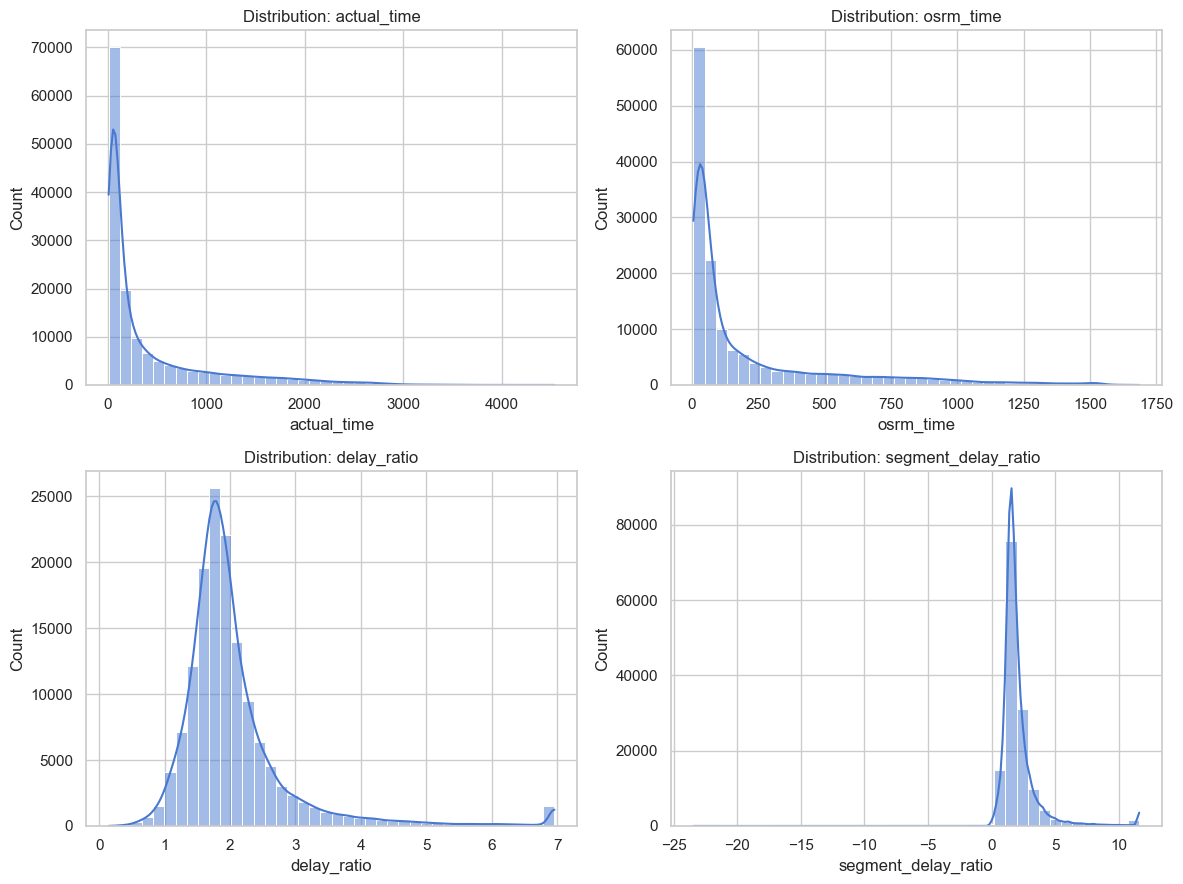

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, UNIVARIATE_COLS):
    data = df[col].dropna()
    # Cap display for very skewed ratios (keeps plots readable)
    if "ratio" in col:
        plot_data = data.clip(upper=data.quantile(0.99))
    else:
        plot_data = data
    sns.histplot(plot_data, kde=True, ax=ax, bins=40)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_univariate_histograms.png", bbox_inches="tight")
plt.show()

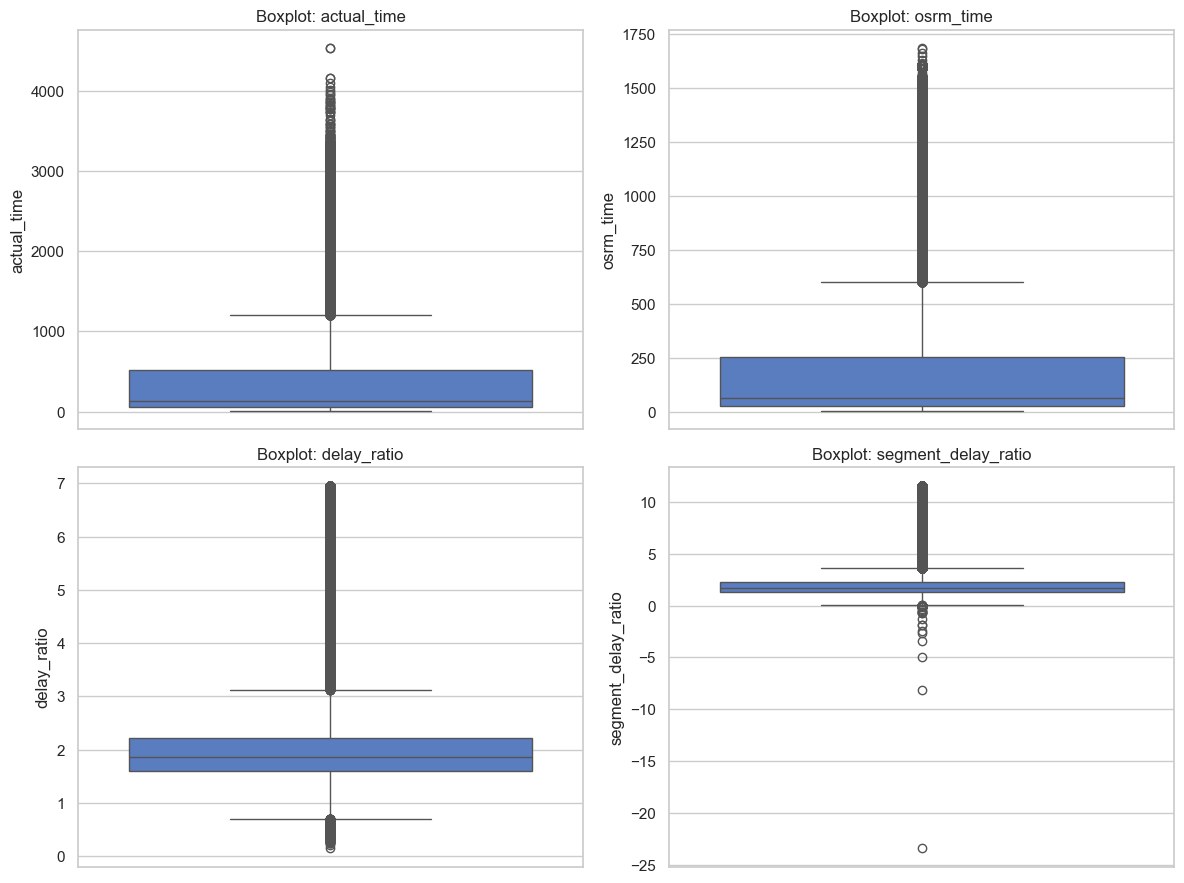

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, UNIVARIATE_COLS):
    plot_df = df[[col]].copy()
    if "ratio" in col:
        cap = df[col].quantile(0.99)
        plot_df[col] = plot_df[col].clip(upper=cap)
    sns.boxplot(data=plot_df, y=col, ax=ax)
    ax.set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_univariate_boxplots.png", bbox_inches="tight")
plt.show()

### Takeaways — univariate

- Time columns (`actual_time`, `osrm_time`) are usually **right-skewed**: many short trips, fewer very long ones.
- **Delay ratios** often skew right too — most segments are near 1× OSRM, but some lanes run much slower.
- High **outlier %** on ratios suggests capping or robust models (e.g. Huber loss, quantile regression) later.

## 6. Data quality — invalid and extreme records

Before modeling, flag rows that would distort training:

| Issue | Rule |
|-------|------|
| Negative times | `actual_time < 0` or `segment_actual_time < 0` |
| Zero OSRM time | `osrm_time == 0` or `segment_osrm_time == 0` |
| Extreme delay ratio | ratio > 99th percentile (data-driven threshold) |

We keep flags as columns so you can filter in preprocessing rather than silently dropping rows here.

In [8]:
EXTREME_DELAY_PCT = 99
extreme_trip = df["delay_ratio"].quantile(EXTREME_DELAY_PCT / 100)
extreme_segment = df["segment_delay_ratio"].quantile(EXTREME_DELAY_PCT / 100)

df["flag_negative_actual"] = df["actual_time"] < 0
df["flag_negative_segment"] = df["segment_actual_time"] < 0
df["flag_zero_osrm"] = df["osrm_time"] == 0
df["flag_zero_segment_osrm"] = df["segment_osrm_time"] == 0
df["flag_extreme_delay"] = df["delay_ratio"] > extreme_trip
df["flag_extreme_segment_delay"] = df["segment_delay_ratio"] > extreme_segment

flag_cols = [c for c in df.columns if c.startswith("flag_")]
df["flag_any_issue"] = df[flag_cols].any(axis=1)

quality_report = pd.DataFrame({
    "issue": [
        "Negative actual_time",
        "Negative segment_actual_time",
        "Zero osrm_time",
        "Zero segment_osrm_time",
        f"Extreme delay_ratio (>{extreme_trip:.2f})",
        f"Extreme segment_delay_ratio (>{extreme_segment:.2f})",
        "Any issue above",
    ],
    "count": [
        df["flag_negative_actual"].sum(),
        df["flag_negative_segment"].sum(),
        df["flag_zero_osrm"].sum(),
        df["flag_zero_segment_osrm"].sum(),
        df["flag_extreme_delay"].sum(),
        df["flag_extreme_segment_delay"].sum(),
        df["flag_any_issue"].sum(),
    ],
})
quality_report["pct_of_rows"] = (quality_report["count"] / len(df) * 100).round(3)
quality_report

,issue,count,pct_of_rows
0,Negative actual_time,0,0.000
1,Negative segment_actual_time,21,0.014
2,Zero osrm_time,0,0.000
3,Zero segment_osrm_time,2347,1.620
4,Extreme delay_ratio (>6.96),1449,1.000
5,Extreme segment_delay_ratio (>11.60),1422,0.982
6,Any issue above,4637,3.201


## 7. Route type comparison — FTL vs Carting

`route_type` distinguishes operational modes. **FTL** (full truck load) often behaves differently from **Carting** (consolidated / hub-and-spoke). We compare time distributions and delay ratios between them.

In [9]:
print("Route type counts:")
print(df["route_type"].value_counts())
print()

route_compare = (
    df.groupby("route_type")[[
        "actual_time", "osrm_time", "delay_ratio",
        "segment_actual_time", "segment_osrm_time", "segment_delay_ratio",
    ]]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
route_compare

Route type counts:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64



actual_time                        osrm_time                 \
                 count    mean median     std     count    mean median   
route_type                                                               
Carting          45207   70.64   48.0   86.45     45207   30.45   24.0   
FTL              99660  574.01  279.0  661.47     99660  297.07  145.0   

                   delay_ratio        ... segment_actual_time         \
               std       count  mean  ...              median    std   
route_type                            ...                              
Carting      21.88       45207  2.41  ...                16.0  50.07   
FTL         339.86       99660  1.99  ...                33.0  54.26   

           segment_osrm_time                      segment_delay_ratio        \
                       count   mean median    std               count  mean   
route_type                                                                    
Carting                45207  10.55    9.0   8.10               43682  2.73   
FTL                    99660  22.12   19.0  15.68               98838  2.07   

                         
           median   std  
route_type               
Carting      1.82  7.19  
FTL          1.67  3.35  

[2 rows x 24 columns]

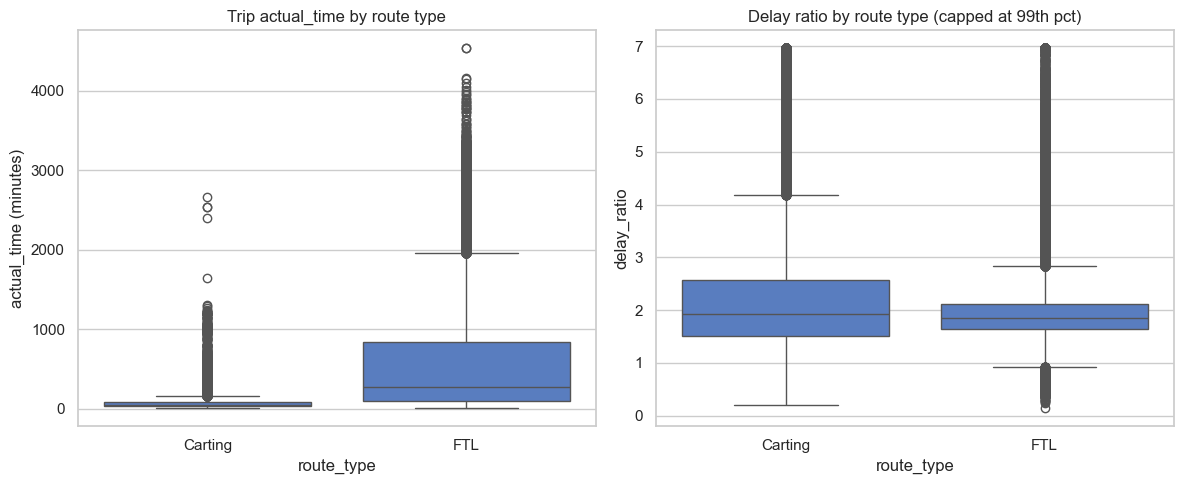

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="route_type", y="actual_time", ax=axes[0])
axes[0].set_title("Trip actual_time by route type")
axes[0].set_ylabel("actual_time (minutes)")

plot_ratio = df.copy()
plot_ratio["delay_ratio"] = plot_ratio["delay_ratio"].clip(upper=plot_ratio["delay_ratio"].quantile(0.99))
sns.boxplot(data=plot_ratio, x="route_type", y="delay_ratio", ax=axes[1])
axes[1].set_title("Delay ratio by route type (capped at 99th pct)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_ftl_vs_carting_boxplots.png", bbox_inches="tight")
plt.show()

## 8. Actual vs OSRM — trip and segment level

If points lie on the diagonal, actual time equals OSRM. Points **above** the line mean slower than predicted by the router.

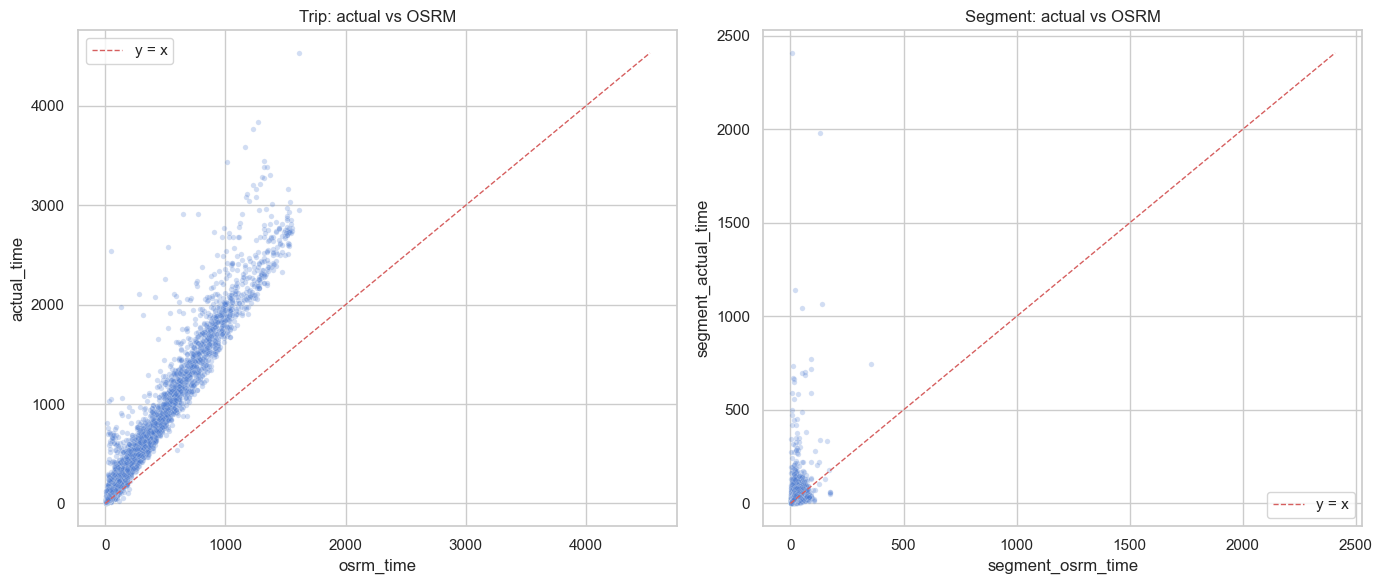

In [11]:
sample_n = min(8_000, len(df))
sample = df.sample(sample_n, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_col, y_col, title in [
    (axes[0], "osrm_time", "actual_time", "Trip: actual vs OSRM"),
    (axes[1], "segment_osrm_time", "segment_actual_time", "Segment: actual vs OSRM"),
]:
    valid = sample[[x_col, y_col]].dropna()
    valid = valid[(valid[x_col] > 0) & (valid[y_col] > 0)]
    sns.scatterplot(data=valid, x=x_col, y=y_col, alpha=0.25, s=15, ax=ax)
    lim = max(valid[x_col].max(), valid[y_col].max())
    ax.plot([0, lim], [0, lim], "r--", lw=1, label="y = x")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_actual_vs_osrm_scatter.png", bbox_inches="tight")
plt.show()

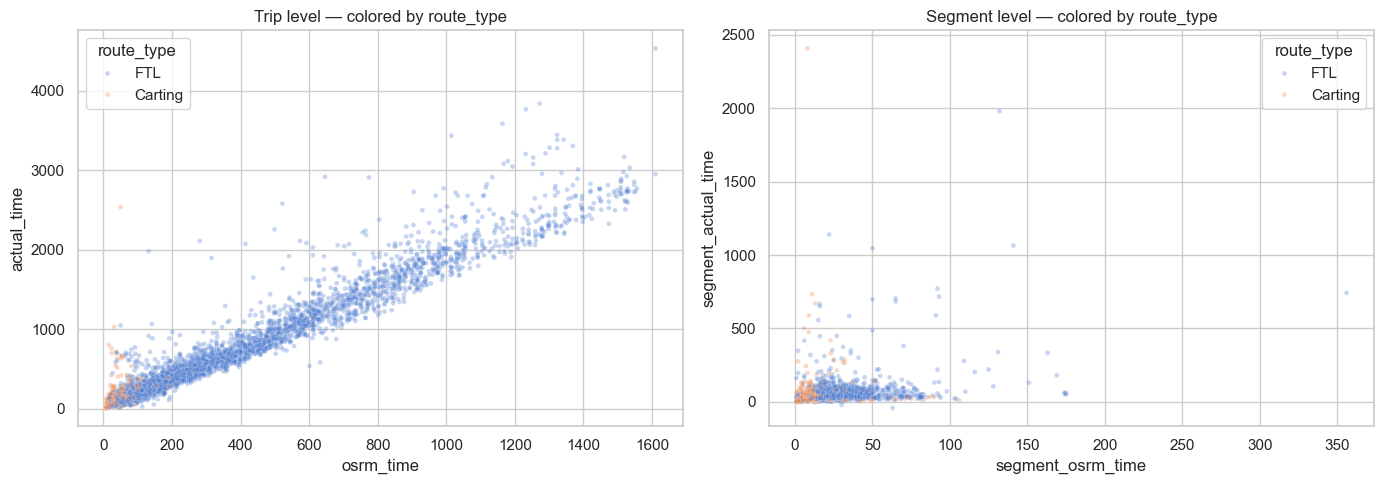

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=sample, x="osrm_time", y="actual_time", hue="route_type",
    alpha=0.3, s=12, ax=axes[0],
)
axes[0].set_title("Trip level — colored by route_type")

seg_sample = sample[(sample["segment_osrm_time"] > 0) & (sample["segment_actual_time"].notna())]
sns.scatterplot(
    data=seg_sample, x="segment_osrm_time", y="segment_actual_time",
    hue="route_type", alpha=0.3, s=12, ax=axes[1],
)
axes[1].set_title("Segment level — colored by route_type")

plt.tight_layout()
plt.show()

## 9. Correlation heatmap

Numeric features that move together may be redundant or useful as model inputs. We correlate key time, distance, and ratio columns.

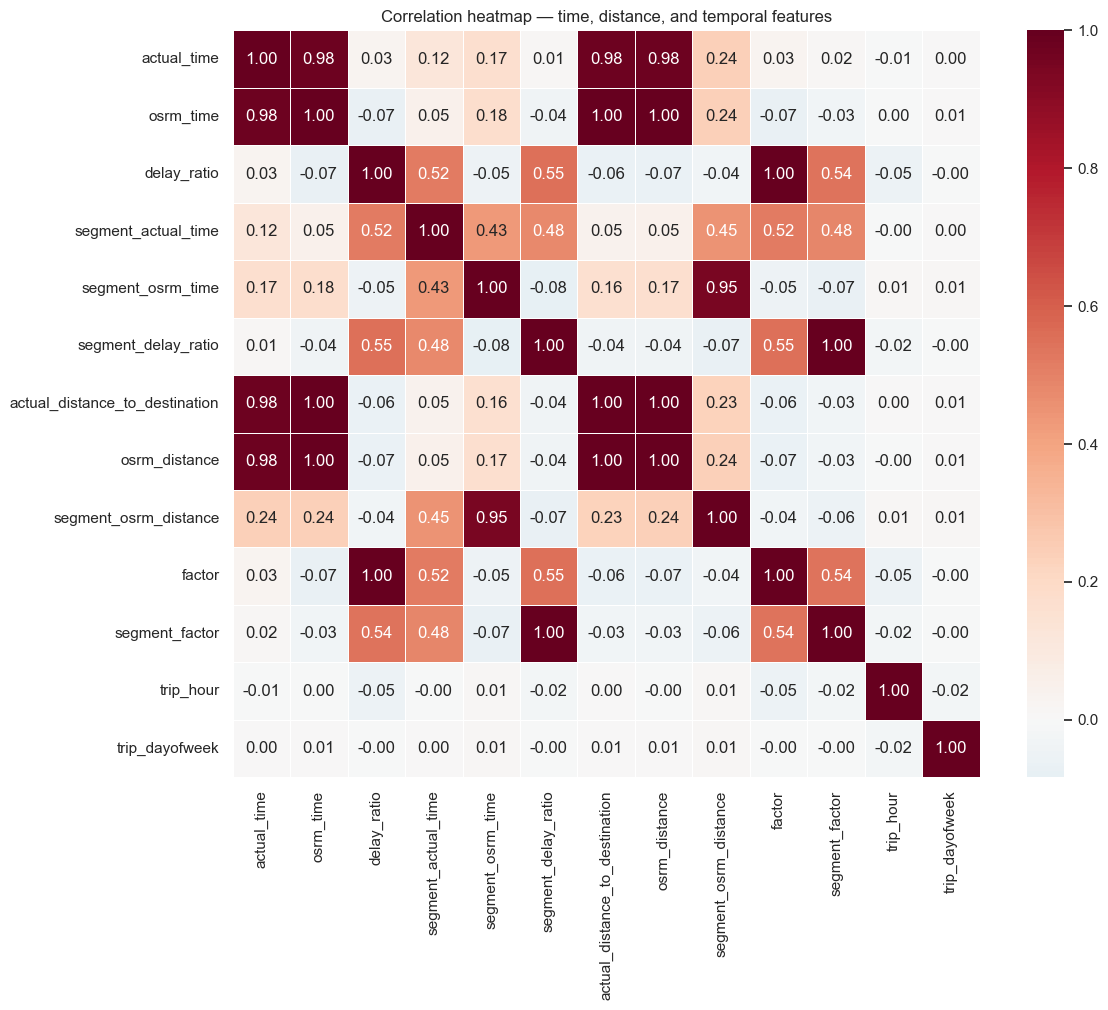

In [13]:
CORR_COLS = [
    "actual_time", "osrm_time", "delay_ratio",
    "segment_actual_time", "segment_osrm_time", "segment_delay_ratio",
    "actual_distance_to_destination", "osrm_distance",
    "segment_osrm_distance", "factor", "segment_factor",
    "trip_hour", "trip_dayofweek",
]

corr_matrix = df[CORR_COLS].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation heatmap — time, distance, and temporal features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 10. Temporal patterns — hour and day of week

Trips created at certain hours or days may systematically run longer. This informs calendar features for ML.

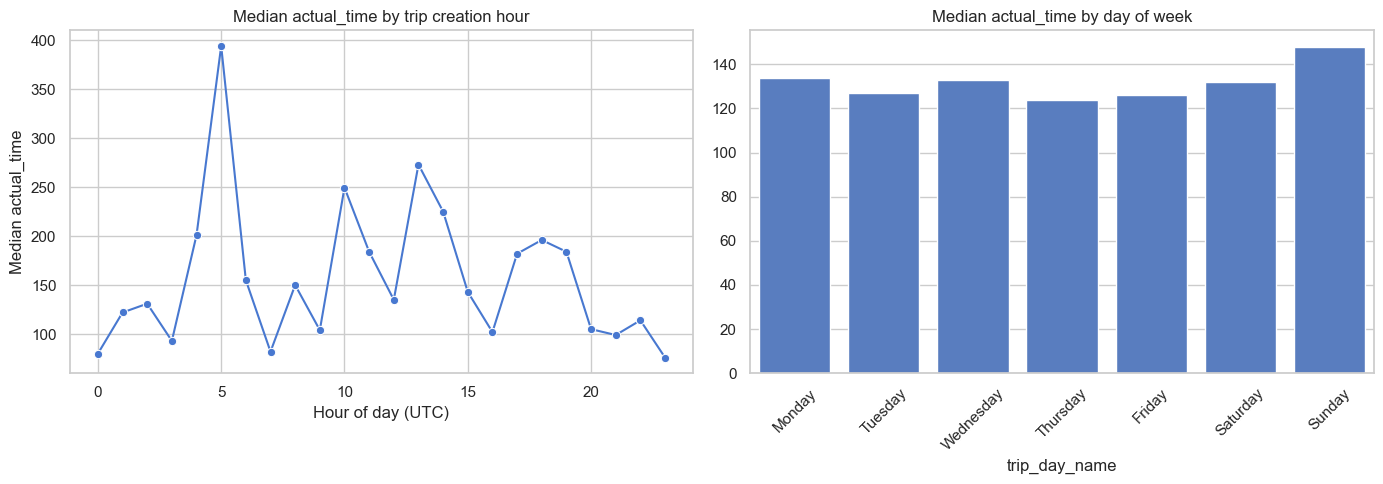

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df.groupby("trip_hour")["actual_time"].median().reset_index()
sns.lineplot(data=hourly, x="trip_hour", y="actual_time", marker="o", ax=axes[0])

axes[0].set_title("Median actual_time by trip creation hour")
axes[0].set_xlabel("Hour of day (UTC)")
axes[0].set_ylabel("Median actual_time")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

dow = df.groupby("trip_day_name")["actual_time"].median().reindex(dow_order)

sns.barplot(x=dow.index, y=dow.values, ax=axes[1])

axes[1].set_title("Median actual_time by day of week")

# FIX
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11. Route intelligence — delays, hubs, and busy lanes

- **Top delayed routes** — lanes (`source → destination`) with highest median `segment_delay_ratio` (minimum volume threshold).
- **Most common hubs** — centers that appear often as source or destination.
- **Busiest OD pairs** — highest trip/segment counts.

In [15]:
MIN_LANE_ROWS = 50  # ignore rare lanes for stable medians

lane_stats = (
    df.groupby("route_lane", as_index=False)
    .agg(
        n_segments=("segment_actual_time", "count"),
        median_segment_delay=("segment_delay_ratio", "median"),
        mean_segment_actual=("segment_actual_time", "mean"),
        mean_segment_osrm=("segment_osrm_time", "mean"),
    )
    .query("n_segments >= @MIN_LANE_ROWS")
    .sort_values("median_segment_delay", ascending=False)
)

print(f"Top 15 delayed routes (≥{MIN_LANE_ROWS} segments, by median segment_delay_ratio):")
top_delayed = lane_stats.head(15).copy()
top_delayed

Top 15 delayed routes (≥50 segments, by median segment_delay_ratio):


,route_lane,n_segments,median_segment_delay,mean_segment_actual,mean_segment_osrm
2264,IND700136AAG → IND712310AAA,50,4.666667,43.020000,8.920000
488,IND212402AAA → IND211002AAB,65,4.285714,209.753846,7.769231
1282,IND462001AAA → IND462022AAA,56,4.000000,37.875000,7.339286
2280,IND712311AAA → IND700065AAA,58,3.437500,42.275862,10.931034
2745,IND851127AAA → IND842001AAA,80,3.414286,79.625000,19.100000
2559,IND785690AAB → IND785682AAA,70,3.380952,36.628571,9.914286
1173,IND421302AAR → IND421004AAA,53,3.222222,21.886792,5.830189
2274,IND712310AAE → IND712124AAA,60,3.200000,36.316667,9.366667
508,IND224141AAB → IND224122AAA,50,3.125000,20.240000,6.200000
2601,IND792130AAB → IND786001AAB,86,3.000000,28.976744,9.302326


In [16]:
source_counts = df["source_center"].value_counts().rename_axis("hub").reset_index(name="as_source")
dest_counts = df["destination_center"].value_counts().rename_axis("hub").reset_index(name="as_destination")

hub_activity = source_counts.merge(dest_counts, on="hub", how="outer").fillna(0)
hub_activity["total_appearances"] = (
    hub_activity["as_source"] + hub_activity["as_destination"]
).astype(int)
hub_activity = hub_activity.sort_values("total_appearances", ascending=False)

print("Top 15 most active hubs (source + destination appearances):")
hub_activity.head(15)

Top 15 most active hubs (source + destination appearances):


,hub,as_source,as_destination,total_appearances
8,IND000000ACB,23347.0,15192.0,38539
1020,IND562132AAA,9975.0,11019.0,20994
672,IND421302AAG,9088.0,5492.0,14580
843,IND501359AAE,3340.0,5142.0,8482
633,IND411033AAA,4061.0,3695.0,7756
1347,IND712311AAA,2612.0,4892.0,7504
33,IND110037AAM,2013.0,3769.0,5782
155,IND160002AAC,2450.0,2874.0,5324
92,IND131028AAB,1682.0,2796.0,4478
1444,IND751002AAB,1469.0,2524.0,3993


In [17]:
od_pairs = (
    df.groupby(["source_center", "destination_center", "source_name", "destination_name"], as_index=False)
    .size()
    .rename(columns={"size": "segment_count"})
    .sort_values("segment_count", ascending=False)
)

print("Top 15 busiest source → destination pairs:")
od_pairs.head(15)

Top 15 busiest source → destination pairs:


,source_center,destination_center,source_name,destination_name,segment_count
57,IND000000ACB,IND562132AAA,Gurgaon_Bilaspur_HB (Haryana),Bangalore_Nelmngla_H (Karnataka),4976
1721,IND562132AAA,IND000000ACB,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),3316
59,IND000000ACB,IND712311AAA,Gurgaon_Bilaspur_HB (Haryana),Kolkata_Dankuni_HB (West Bengal),2862
55,IND000000ACB,IND501359AAE,Gurgaon_Bilaspur_HB (Haryana),Hyderabad_Shamshbd_H (Telangana),1639
52,IND000000ACB,IND421302AAG,Gurgaon_Bilaspur_HB (Haryana),Bhiwandi_Mankoli_HB (Maharashtra),1617
1121,IND421302AAG,IND000000ACB,Bhiwandi_Mankoli_HB (Maharashtra),Gurgaon_Bilaspur_HB (Haryana),1269
2475,IND781018AAB,IND110037AAM,Guwahati_Hub (Assam),Delhi_Airport_H (Delhi),1137
1147,IND421302AAG,IND562132AAA,Bhiwandi_Mankoli_HB (Maharashtra),Bangalore_Nelmngla_H (Karnataka),1131
51,IND000000ACB,IND411033AAA,Gurgaon_Bilaspur_HB (Haryana),Pune_Tathawde_H (Maharashtra),1120
58,IND000000ACB,IND600056AAB,Gurgaon_Bilaspur_HB (Haryana),MAA_Poonamallee_HB (Tamil Nadu),1015


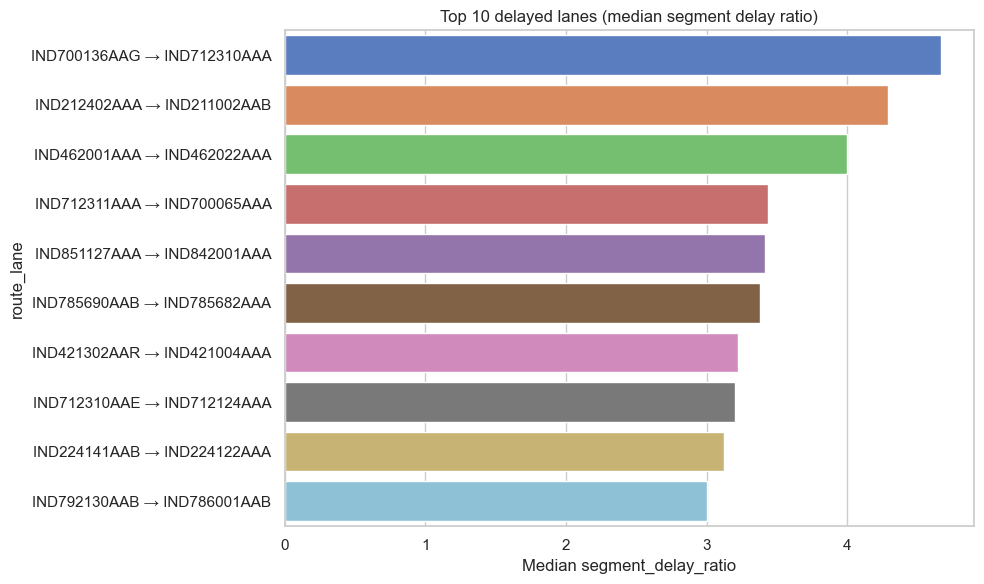

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
top_lanes_plot = top_delayed.head(10)
sns.barplot(
    data=top_lanes_plot,
    y="route_lane",
    x="median_segment_delay",
    ax=ax,
    hue="route_lane",
    dodge=False,
    legend=False,
)
ax.set_title("Top 10 delayed lanes (median segment delay ratio)")
ax.set_xlabel("Median segment_delay_ratio")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_top_delayed_lanes.png", bbox_inches="tight")
plt.show()